# <font color='orange'>TME ROBOTIQUE ET APPRENTISSAGE</font>
# <font color='orange'>3. Stratégies d'évolution pour la robotique collective</font>

# <font color="green">Version ETUDIANT·E·S 2025-2026</font>


*mise à jour: 26/3/2026*

Ce notebook doit être exécuté dans [Google Colab](colab.research.google.com/) ou dans Jupyter.

A la fin du TME, vous devez déposer votre travail sur Moodle:
* déposer votre notebook, avec le nom de fichier *obligatoirement* au format suivant: **RA_NOM1_NOM2.ipynb**
* toutes les cellules doivent être exécutées avec les graphes visibles
* un **bref** commentaire lorsque c'est demandé. Pour toutes les questions, une à deux phrases suffisent

*Le sujet est à faire en binome.*

# COMPLETEZ LES CHAMPS CI-DESSOUS AVEC NOM/PRENOM/CARTE_ETU:

* Étudiant 1: **Oundjian Milos 21500050**
* Étudiant 2: **Antipin Vladislav 21242244**




*contact: NB@SU 2024-03-28*


In [177]:
from datetime import datetime
from datetime import date
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import numpy as np
import math
import random
import sys

# !pip install cma
import cma

#### #### ####

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")


 2026-03-26 17:35:54 GMT
OK.


In [178]:
#############################
### 0. Experimental setup ###
#############################

max_iterations = 5001

absolute_orientation = 0 #-90  # degrees
translation_per_step = 1.0 #1.0 # 6.0  # in [0,1]
max_translation_per_step = 1.0 # >0. pixel per move.
rotation_per_step = 0.0 # in [-1,1]
max_rotation_per_step = 3.0 # >0, in degrees

arena_size = 100 # 50
sensor_length = 10
nb_sensors = 8

particle_box = 3 # bounding box (square)

particle = np.zeros((particle_box, particle_box), dtype=int)

# Drawing a circle in the particle array
#particle_radius_real = particle_box / 2 - 0.5  # Radius of the circle in the particle
#center_particle_real = (particle_box / 2 - 0.5, particle_box / 2 - 0.5)  # Real center of the particle
particle_radius_real = particle_box / 2.0  # Radius of the circle in the particle
center_particle_real = (particle_box / 2 - 0.5, particle_box / 2 - 0.5)  # Real center of the particle

####################
### 1. Structure ###
####################

def init(): # perform only once
  global particle,center_particle_real,particle_radius_real,robots_count

  for i in range(particle.shape[0]):
      for j in range(particle.shape[1]):
          # Check if the cell falls within the circle radius
          if ((i - center_particle_real[0])**2 + (j - center_particle_real[1])**2) <= particle_radius_real**2:
              particle[i, j] = 2
          else:
            particle[i, j] = 3

  init_arena()
  init_trace()
  init_occupancy()

  robots_count = 1

def init_arena():
  global arena
  arena = np.zeros((arena_size, arena_size), dtype=int)

def init_trace():
  global trace
  trace = np.zeros((arena_size, arena_size), dtype=int)

def init_occupancy():
  global occupancy
  occupancy = np.zeros((arena_size, arena_size), dtype=int)

def clear_arena(): # clear content, except for wall
  global arena
  #arena[:] = 0
  arena[arena != 1] = 0

def clear_trace(): # clear content, except for wall
  global trace
  #trace[:] = 0
  trace[trace != 1] = 0

def clear_occupancy(): # clear content
  global occupancy
  occupancy[:,:] = 0

def draw_line(x1, y1, x2, y2, color): # do not draw on wall
    global arena
    num_points = max(abs(x2 - x1), abs(y2 - y1)) + 1
    x_points = np.linspace(x1, x2, num_points, dtype=int)
    y_points = np.linspace(y1, y2, num_points, dtype=int)
    # shorte, not border-protected:
    # arena[y_points, x_points] = color
    # longer, border-protected:
    for i in range(len(x_points)):
      if y_points[i] >= 0 and y_points[i] < arena.shape[0] and x_points[i] >= 0 and x_points[i] < arena.shape[1]:
        if arena[y_points[i],x_points[i]] != 1:
          arena[y_points[i],x_points[i]] = color

def cast_sensor(x1, y1, x2, y2, color=6):
    global arena, display_cast
    num_points = max(abs(x2 - x1), abs(y2 - y1)) + 1
    x_points = np.linspace(x1, x2, num_points, dtype=int)
    y_points = np.linspace(y1, y2, num_points, dtype=int)
    max_distance = math.sqrt( (x_points[0]-x_points[-1])**2 + (y_points[0]-y_points[-1])**2 ) - particle_radius_real
    for i in range(len(x_points)):
      if y_points[i] >= 0 and y_points[i] < arena.shape[0] and x_points[i] >= 0 and x_points[i] < arena.shape[1]:
        if arena[y_points[i],x_points[i]] == 1 or arena[y_points[i],x_points[i]] == 2  or arena[y_points[i],x_points[i]] == 4:
          if verbose:
            print ("DETECT OBJECT at",i)
          return ( math.sqrt( (x_points[0]-x_points[i])**2 + (y_points[0]-y_points[i])**2 ) - particle_radius_real ) / max_distance # distance to obstacle, normalize in [0,1]
        elif display_cast == True:
          arena[y_points[i],x_points[i]] = color
    return 1.0

translation_per_step = 0.0  # in units
rotation_per_step = 0.0  # in degrees

############################
### 2. General functions ###
############################

def create_wall(x1, y1, x2, y2):
    arena[max(y1, 0):min(y2, arena_size), max(x1, 0):min(x2, arena_size)] = 1
    if display_trace:
      trace[max(y1, 0):min(y2, arena_size), max(x1, 0):min(x2, arena_size)] = 1

def get_sensors(x, y, theta): # 8 sensors belt
    global sensor_length, nb_sensors

    source_x, source_y = int(x+particle_radius_real-1), int(y+particle_radius_real-1)

    sensor_values = []
    for i in range(nb_sensors):
      offset_x = math.cos(math.radians(theta+i*360.0/nb_sensors)) * sensor_length
      offset_y = math.sin(math.radians(theta+i*360.0/nb_sensors)) * sensor_length
      target_x = int(source_x + offset_x + 0.5)
      target_y = int(source_y - offset_y + 0.5)
      sensor_values.append( cast_sensor(int(source_x),int(source_y),target_x,target_y,6) )

    return sensor_values

def clean_sensors(x, y, theta): # 8 sensors belt
    global sensor_length, nb_sensors

    if display_cast == False:
      return

    source_x, source_y = int(x+particle_radius_real-1), int(y+particle_radius_real-1)

    sensor_length = 10
    nb_sensors = 8

    sensor_values = []
    for i in range(nb_sensors):
      offset_x = math.cos(math.radians(theta+i*360.0/nb_sensors)) * sensor_length
      offset_y = math.sin(math.radians(theta+i*360.0/nb_sensors)) * sensor_length
      target_x = int(source_x + offset_x + 0.5)
      target_y = int(source_y - offset_y + 0.5)
      draw_line(int(source_x),int(source_y),target_x,target_y,0)

    return sensor_values

def place_particle(x, y, theta, robot_id):
    global arena, particle
    x, y = int(x), int(y)
    arena_slice = arena[y:y+particle_box, x:x+particle_box]

    # Check for overlap between particle and non-zero cells in the arena
    #collision = np.logical_and(arena_slice == 1, particle == 2)
    collision = np.logical_and(arena_slice != 0, particle == 2) # 2024-03-25
    if np.any(collision):
        collision_array = np.where(collision, 3, particle)
        return collision_array

    #arena_slice[ int(math.cos(theta)*particle_box/2) , int(math.sin(theta)*particle_box/2) ] = 3 # display particle front
    #arena[y:y+particle_box, x:x+particle_box] += np.where(arena_slice == 0, particle, 0)

    for i in range(particle_box):
      for j in range(particle_box):
        if arena[y+i, x+j] == 0 or arena[y+i, x+j] == 4 or arena[y+i, x+j] == 6:
          arena[y+i, x+j] = 2

    trace[int(y + particle_box / 2.),int(x + particle_box / 2.)] = 2
    occupancy[int(y + particle_box / 2.),int(x + particle_box / 2.)] = robot_id
    


    if verbose:
      print("location",x+particle_box/2.0,y+particle_box/2.0)
      print("absolute_orientation", theta)

    offset_x = math.cos(math.radians(theta)) * particle_box / 2.0 * .999
    offset_y = math.sin(math.radians(theta)) * particle_box / 2.0 * .999
    x_head = int(x + particle_box / 2. + offset_x )
    y_head = int(y + particle_box / 2. - offset_y )
    if verbose:
      print ("y_head, x_head",y_head, x_head)

    arena[y_head, x_head] = 4  # Display particle front

    return None

def erase_particle(x, y):
    global arena, particle
    x, y = int(x), int(y)
    #arena[y:y+particle_box, x:x+particle_box] -= particle * (arena[y:y+particle_box, x:x+particle_box] != 0)
    for i in range(particle_box):
      for j in range(particle_box):
        if arena[y+i, x+j] == 2 or arena[y+i, x+j] == 4:
          arena[y+i, x+j] = 0

def draw(arena,double_size=False):

    if double_size == True:
      doubled_figsize = (12.8, 9.6)
      plt.figure(figsize=doubled_figsize)

    cmap = colors.ListedColormap(['white', 'black', 'grey', 'red', 'orange', 'green'])
    bounds = [0, 1, 2, 3, 4, 5, 6]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    plt.imshow(arena, cmap=cmap, norm=norm)
    plt.colorbar(ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], format=plt.FuncFormatter(lambda x, _: {0.5: '0 - nothing', 1.5: '1 - obstacle', 2.5: '2 - robot', 3.5: '3 - collision', 4.5: '4 - robot front', 5.5: '5 - sensor ray'}[x]))
    plt.show()

def show_arena():
  draw(arena,double_size=False)

def show_trace():
  draw(trace,double_size=False)
  
def show_occupancy():
  draw(occupancy,double_size=False)


####################################
### 3. PARTICLE UPDATE functions ###
####################################

def update_particle_position(x, y, theta, translation_per_step, rotation_per_step, iteration, noiseFlag = False):
  '''
  Function called to update particle position (and orientation). It should merge the desired control command from the user (translation_per_step and rotation_per_step) and the physics of environment and particle.
  Below is a simple example where desired translation and rotation per step are applied directly (ideal: no friction, unbounded bang-bang controller)
  Add whatever you need as persistent internal data.

  # x, y: position of the particle (real values)
  # theta (absolute_orientation): particle absolute orientation wrt an external referential (0° points rightward, trigonometric, use degree)
  # translation_per_step, rotation_per_step: *desired* value by the controller/user. I.e.: values are applied if no friction, no inertia, no collision (see example below)
  # iteration: simulator iteration number (may be ignored)
  '''

  new_orientation = theta + rotation_per_step

  # Sinusoidal noise for rotation (optional)
  if noiseFlag == True:
    noise = 10 * math.sin(2 * math.pi * iteration / 5)
    new_orientation += noise

  # Convert orientation to radians for calculation
  orientation_radians = math.radians(new_orientation)

  new_x = x + translation_per_step * math.cos(orientation_radians)
  new_y = y - translation_per_step * math.sin(orientation_radians)  # Minus sign due to y-axis inversion in image coordinates

  return new_x, new_y, new_orientation


def update_particle_dynamics(x, y, absolute_orientation, translation_per_step, rotation_per_step, iteration, collision_array ):
  '''
  Function called to udpate internal data (to be defined here) in case of a collision event.
  This function does not move the robot. Updating the absolute_orientation is possible, as well as (to be defined) internal data structure (e.g. encoding the effect of inertia)
  Note that when a particle experience a collision, the collision is recorded (see collision_array) and move is cancelled.
  The goal of this function is to compute/update all necessary information to call later the update_particle_position function.
  Add whatever you need as persistent internal data.

  # x, y: position of the particle (real values)
  # absolute_orientation: particle absolute orientation wrt an external referential (0° points rightward, trigonometric, use degree)
  # translation_per_step, rotation_per_step: *desired* value by the controller/user. I.e.: values are applied if no friction, no inertia, no collision (see example below)
  # iteration: simulator iteration number (may be ignored)
  # iteration: simulator iteration number (may be ignored)
  # collision_array: integer array showing the particle state within its bounding box. 0 for nothing, 1 for particle elements, 2 for particle elements experiencing a collision event

  Testing: essaye avec translation_per_step=1.0, puis avec translation_per_step=6.0 (cas intéressant du a la faible épaisseur du mur)
  '''

  # do nothing for now.

  return absolute_orientation


#######################
### 4. Main loop    ###
#######################


robots_count = 1

class Robot:
    x0, y0, theta_0, x,y,theta = 0,0,0,0,0,0
    id = -1
    log_sum_of_translation = 0 # logging
    log_sum_of_rotation = 0 # logging

    def __init__(self, x_0, y_0, theta_0):
      global robots_count
      self.x0 = self.x = x_0
      self.y0 = self.y = y_0
      self.theta0 = self.theta = theta_0
      self.id = robots_count
      robots_count = robots_count + 1

    def reset(self):
      self.log_sum_of_rotation = 0
      self.log_sum_of_translation = 0
      self.x = self.x0
      self.y = self.y0
      self.theta = self.theta0

    def step(self,sensors):
      translation, rotation = 0,0
      return translation, rotation

# parameters
  # initial x and y position and orientation
  # step controller function which returns translation/rotation (in [-1,1]) from sensors (in [0,1])
# returns:
  # sum of actual translations in [0,1]. Normalized over time and max translation.
  # sum of rotation, absolute value normalized value in [0,1]. Normalized over time and max rotation.
  # number of pixels of arena visited (unique location, ie. visited twice counts as 1)
  # particle's x coordinate at the end
  # particle's y coordinate at the end
def simulate(my_robots):
  global x_particle,y_particle,absolute_orientation,trace,occupancy

  clear_arena()
  clear_trace()
  clear_occupancy()

  for k in range(len(my_robots)):
    #k = 0
    #x_particle, y_particle = x0, y0
    #absolute_orientation = orientation0
    #sensors = get_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
    collision_array = place_particle(my_robots[k].x, my_robots[k].y, my_robots[k].theta, my_robots[k].id)

    if collision_array is not None:
      print("[ERROR] initial location triggers collision.")
      sys.exit()

  iteration = 0

  while iteration < max_iterations:
      if verbose_minimal_progress == True and iteration%gap_between_display_minimal_progress == 0:
        print ("### iteration",iteration,"/",max_iterations,"###")

      for k in range(len(my_robots)):

        # necessary to update sensors as the world may have changed
        erase_particle(my_robots[k].x, my_robots[k].y)
        clean_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
        sensors = get_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
        #place_particle(my_robots[k].x, my_robots[k].y, my_robots[k].theta, my_robot[k].id)

        translation_per_step,rotation_per_step = my_robots[k].step(sensors)

        my_robots[k].log_sum_of_rotation += abs((max(-1.,min(+1.,rotation_per_step)))) # logging

        #erase_particle(my_robots[k].x, my_robots[k].y)
        #clean_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
        backup_x_particle, backup_y_particle = my_robots[k].x, my_robots[k].y
        my_robots[k].x, my_robots[k].y, my_robots[k].theta = update_particle_position(my_robots[k].x, my_robots[k].y, my_robots[k].theta, (max(-1.,min(+1.,translation_per_step)))*max_translation_per_step, (max(-1.,min(+1.,rotation_per_step)))*max_rotation_per_step, iteration ,noiseFlag=False)
        sensors = get_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
        collision_array = place_particle(my_robots[k].x, my_robots[k].y, my_robots[k].theta, my_robots[k].id)
        if collision_array is not None: # collision occured
            if verbose == True:
                print("Collision detected!")
            if display_collision:
                print(collision_array)
            clean_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
            my_robots[k].x, my_robots[k].y = backup_x_particle, backup_y_particle
            sensors = get_sensors(my_robots[k].x, my_robots[k].y, my_robots[k].theta)
            if display_collision:
                draw(collision_array)  # Draw the collision array
            my_robots[k].theta = update_particle_dynamics(my_robots[k].x, my_robots[k].y, my_robots[k].theta, (max(-1.,min(+1.,translation_per_step)))*max_translation_per_step, (max(-1.,min(+1.,rotation_per_step)))*max_rotation_per_step, iteration, collision_array)
            place_particle(my_robots[k].x, my_robots[k].y, my_robots[k].theta, my_robots[k].id)
            if verbose:
                print("Backtrack")

        if my_robots[k].x != backup_x_particle or my_robots[k].y != backup_y_particle:
          my_robots[k].log_sum_of_translation += math.sqrt( ( my_robots[k].x - backup_x_particle )**2 + ( my_robots[k].y - backup_y_particle)**2 )  # logging

      if display_arena == True:
        draw(arena)  # Draw the arena at each step
      if verbose == True:
        print(arena)
      iteration = iteration + 1

  log_pixels_visited = np.sum(trace == 2)
  
  
  # NOTE
  individual_coverages = np.empty(nb_robots)
  for i in range(nb_robots):
      individual_coverages[i] = np.sum(occupancy == i+1)

  log_total_sum_of_translation, log_total_sum_of_rotation = 0,0
  for k in range(len(my_robots)):
    log_total_sum_of_translation += my_robots[k].log_sum_of_translation
    log_total_sum_of_rotation += my_robots[k].log_sum_of_rotation

  retValues = {
      "translations": log_total_sum_of_translation/max_iterations,
      "rotations": log_total_sum_of_rotation/max_iterations,
      "coverage": log_pixels_visited/(arena_size**2),
      "individual_coverages": individual_coverages /(arena_size**2) # NOTE
      #"x_pos_end": x_particle,
      #"y_pos_end": y_particle,
      #"theta_end": absolute_orientation
  }

  return retValues


#### #### ####

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")


 2026-03-26 17:35:54 GMT
OK.


---
---
---

# <font color='orange'>PREAMBULE: initialisation</font>

# Simulateur robot

Il n'est pas nécessaire de regarder le code de ces cellules, elles sont utiles pour les fonctions utilisées dans les parties suivantes.

Remarque: *il suffit d'exécuter ces cellules une seule fois par instance de noyau.*

# Fonctions utiles (construction d'arènes)

Exécutez. Vous pouvez étudier, voire étendre le contenu.

Remarque: create_arena_walls() doit être appelé systématiquement lors de la création d'une nouvelle arène.


In [179]:

def create_arena_walls(): # arena walls are *mandatory* to enclose the robot into a closed arena (otherwise: code will fail with out-of-bounds at some point)
  global arena_size
  create_wall(0, 0, arena_size, 1)
  create_wall(0, arena_size-1, arena_size, arena_size)
  create_wall(0, 0, 1, arena_size)
  create_wall(arena_size-1, 0, arena_size, arena_size)

def create_wall_1():
  global arena_size
  create_wall(arena_size//2+13, arena_size//2-10, arena_size//2+16, arena_size//2+10)

def create_wall_2(y_shift=0):
  global arena_size
  create_wall(arena_size//2+13, arena_size//2-10+y_shift, arena_size//2+16, arena_size//2+10+y_shift)
  create_wall(arena_size//2-16, arena_size//2-10+y_shift, arena_size//2-13, arena_size//2+10+y_shift)
  create_wall(arena_size//2-13, arena_size//2-10+y_shift, arena_size//2+13, arena_size//2-7+y_shift)
  create_wall(arena_size//2-13, arena_size//2+7+y_shift, arena_size//2-2, arena_size//2+10+y_shift)
  create_wall(arena_size//2+3, arena_size//2+7+y_shift, arena_size//2+13, arena_size//2+10+y_shift)

#### #### ####

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")


 2026-03-26 17:35:54 GMT
OK.


# Initialisation des paramètres expérimentaux et des options recommandées d'affichage de messages

In [180]:
# experimental settings

arena_size = 100
max_translation_per_step = 1.0 # >0. pixel per move.
max_rotation_per_step = 10.0 # >0, in degrees
max_iterations = 5001 # nb of simulator iterations for evaluating one robot

# default values for display debug (may be changed later)

verbose_minimal_progress = True # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
gap_between_display_minimal_progress = int(max_iterations/5) # used if verbose_minimal_progress = True
verbose = False # suggested: False -- used for debug
display_collision = False # suggested: False -- used for debug
display_arena = False # suggested: False -- if True, display arena for *all* iterations
display_trace = True # suggested: True
display_cast = False # suggested: False -- if True, display sensor ray casting for *all* iterations (even w/o display)

#### #### ####

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")


 2026-03-26 17:35:54 GMT
OK.


---
---
---

#<font color="orange">Partie 1. Prise en main : simulation robotique collective</font>

Le robot dispose de 8 senseurs (tous ne seront pas utilisés dans la suite) et de deux commandes motrices (translation et rotation). Toutes les commandes sont normalisées (senseurs dans [0,1], translation et rotation dans [-1,+1]).

Les dimensions du robot sont de 2x2 unités. Une unité correspond à un pixel. Cependant, même si l'affichage est discret, le robot se déplace de manière continue dans l'environnement (position/orientation sont des valeurs réelles). La gestion des collisions est faîtes de manière discrète, les déplacements et la mise à jour des valeurs senseurs est faite sur la base de valeurs continues.

La structure des senseurs est la suivante:
  - [0] avant
  - [1] avant-gauche
  - [2] gauche
  - [3] arrière-gauche
  - [4] arrière
  - [5] arrière-droite
  - [6] droite
  - [7] avant-droite

L'orientation est définie comme suit:
  - *absolute_orientation* est utilisé à l'initialisation pour positionner le robot. la valeur 0 indique que le robot pointe vers la droite de l'arène. =-90 vers le bas. etc. (sens trigonométrique)
  - *rotation* est une commande motrice du robot. Elle s'exprime dans le sens trigonométrique (le robot tourne à gauche si inférieure à 0). Elle est définie entre -1 et +1. Cependant, la rotation effective dépend du paramètre * max_rotation_per_step* (non modifiable), qui donne l'angle de rotation maximum possible entre deux itérations du simulateur.
  - exemple: une rotation de -1.0 sachant que max_rotation_per_step=10 provoque une rotation dans le sens inverse des aiguilles d'une montre de 10° par itération.

La translation est définie comme suit:
  - entre -1 (vitesse max. en arrière) et 1 (vitesse max. en avant). pas de déplacement si la translation vaut 0.
  - la translation effective dépend du paramètre *max_translation_per_step* (non modifiable) qui donne le nombre d'unité de déplacement maximum par itération de l'algorithme.
  - exemple: une translation de -0.5 sachant que max_translation_per_step=10 provoque une translation vers l'arrière de 5 unités par itération.
  - Remarque: la notion d'avant et d'arrière est arbitraire. En pratique, cette asymétrie est une interprétation que nous faisons en observant le comportement. En particulier, le résultat d'une optimisation peut *vous* donner l'*impression* que le robot se déplace en reculant (cf. suite du sujet), mais cette observation n'a pas de sens du point de vue du robot (en particulier si les senseurs sont disposés de manière symétrique, ce qui est le cas ici).

<font color="red">EXERCICES:</font>

- Etudiez et exécutez les deux cellules suivantes. La première montre comment programmer plusieurs robots et simuler un environnement. La seconde, plus pertinente pour la suite, montre comment implémenter un réseau de neurones artificiels simples pour le contrôle d'un robot, puis la création de plusieurs robots dont les paramètres de réseaux de neurones sont tirés au hasard, puis testé en simulation. Vous observerez en particulier les informations sur le nombre de "cellules" couvertes, c'est à dire le nombre d'endroits dans l'arène ou un robot est passé en dernier.



# Des robots controllés par un comportement fixe: explorateurs et allons-tout-droit

#
# Multi-robots - ad hoc controllers 
#
### iteration 0 / 501 ###

Statistiques:
	 translations      : 1.161941290819779
	 rotations         : 0.17429484315830496
	 couverture        : 0.0544

  Robot #1 captured 466 cells
  Robot #2 captured 74 cells
  Robot #3 captured 2 cells
  Robot #4 captured 2 cells
# Final state


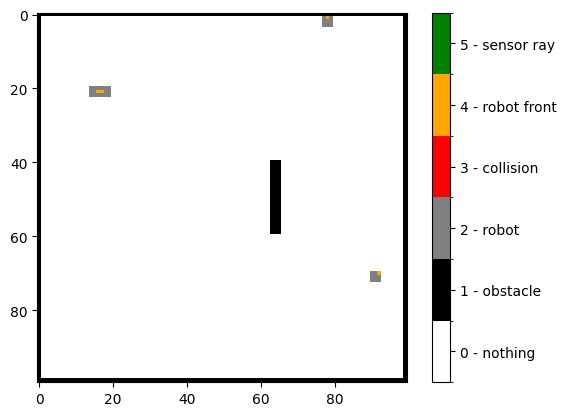

# Trajectory


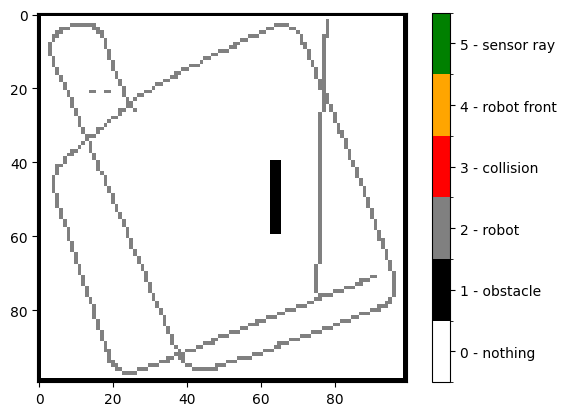

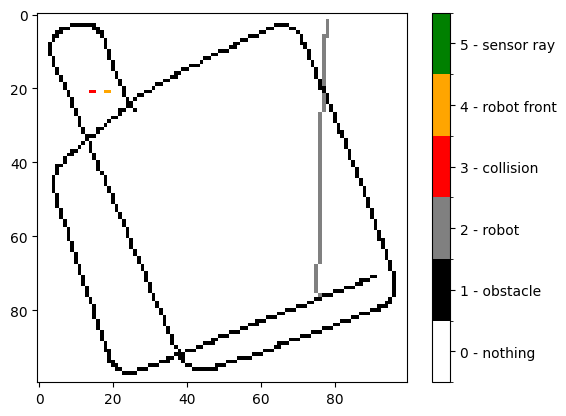

In [181]:
# policy function


class Robot_Explorer(Robot):
  def step(self,sensors):
    translation = sensors[0]
    rotation = 1.0*sensors[1] - 1.0*sensors[-1] + (random.random()-0.5)*0.1
    return translation, rotation

class Robot_Dumb(Robot):
  def step(self,sensors):
    translation = 1.0
    rotation = 0.
    return translation, rotation

# Main

init()

print ("#\n# Multi-robots - ad hoc controllers \n#")

max_iterations = 501

display_arena=False # diplay step-by-step if True.
verbose_minimal_progress = True # suggested: True -- useful. Tune gap_between_... to limit the nb of messages

#clear_arena()
create_arena_walls()
create_wall_1()

#theta_init = 0

nb_robots = 4
robots = []
x_center = arena_size//2 - particle_box/2
y_center = arena_size//2 - particle_box/2

robots.append( Robot_Explorer( arena_size//4,arena_size//4, random.randint(-180,180) ) )
robots.append( Robot_Explorer( 3*arena_size//4, 3*arena_size//4, 90 ) )

robots.append( Robot_Dumb( 13, 20, 0 ) )
robots.append( Robot_Dumb( 18, 20, 180 ) )

retValues = simulate(robots)

print ()
print ("Statistiques:")
print ("\t translations      :", retValues['translations']) # Somme des valeurs absolues de translations. valeurs normalisées entre 0 et 1.
print ("\t rotations         :", retValues['rotations']) # Somme des valeurs absolues de rotations. Valeur normalisée entre 0 et 1.
print ("\t couverture        :", retValues['coverage']) # taux de couverture. Valeur normalisée entre 0 et 1 (arène entièrement couverte).
print ()

robot_ids, visited_cells = np.unique(occupancy, return_counts=True)
for value, count in zip(robot_ids, visited_cells):
  if value != 0:
    print(f"  Robot #{value} captured {count} cells")


print ("# Final state")
show_arena()

print ("# Trajectory")
show_trace()
show_occupancy()


Two dumb robots are intentionally initialized facing each other and thus are stuck, and two other robots-explorrer explore the environment and get final coverage or 0.0882.

# Des robots controllés par réseaux de neurones avec paramètres fixés au hasard

#
# Multi-robots - random search on ANN controller
#
Robot no. 1 is alive
Robot no. 2 is alive
Robot no. 3 is alive
Robot no. 4 is alive
run no. 1 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 2.1101086344617146, 'rotations': 1.7114038046318278, 'coverage': np.float64(0.0319), 'individual_coverages': array([0.0196, 0.0036, 0.0064, 0.0023])}


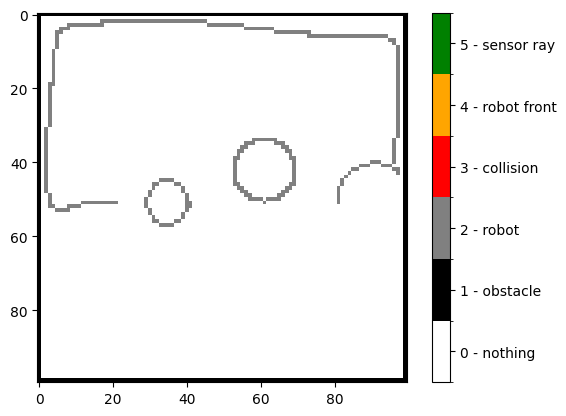

Grid occupancy per robot:
  Robot #1 captured 196 cells
  Robot #2 captured 36 cells
  Robot #3 captured 64 cells
  Robot #4 captured 23 cells
run no. 2 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 2.121510275926444, 'rotations': 2.711346265285386, 'coverage': np.float64(0.0324), 'individual_coverages': array([0.0038, 0.0049, 0.0055, 0.0182])}


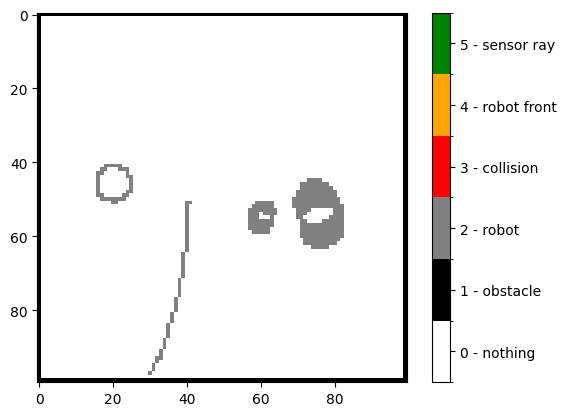

Grid occupancy per robot:
  Robot #1 captured 38 cells
  Robot #2 captured 49 cells
  Robot #3 captured 55 cells
  Robot #4 captured 182 cells
run no. 3 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 2.654669065027545, 'rotations': 3.1705005373812076, 'coverage': np.float64(0.0698), 'individual_coverages': array([0.0585, 0.0069, 0.0034, 0.001 ])}


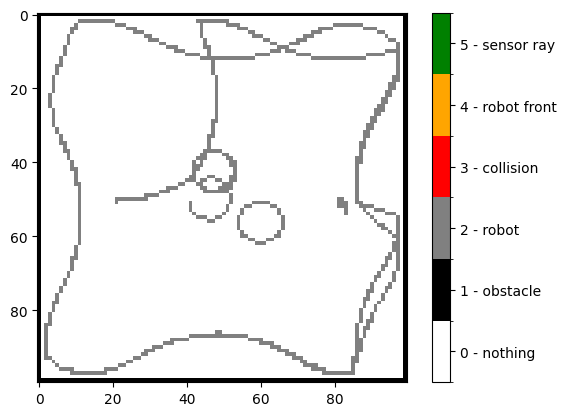

Grid occupancy per robot:
  Robot #1 captured 585 cells
  Robot #2 captured 69 cells
  Robot #3 captured 34 cells
  Robot #4 captured 10 cells
run no. 4 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 2.0663762334124547, 'rotations': 2.1622104353258353, 'coverage': np.float64(0.0142), 'individual_coverages': array([0.0079, 0.0003, 0.0035, 0.0025])}


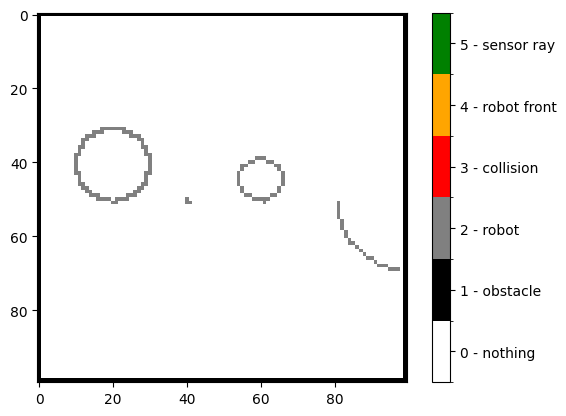

Grid occupancy per robot:
  Robot #1 captured 79 cells
  Robot #2 captured 3 cells
  Robot #3 captured 35 cells
  Robot #4 captured 25 cells
run no. 5 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 1.6716711435804423, 'rotations': 2.1939669378716364, 'coverage': np.float64(0.0489), 'individual_coverages': array([0.0019, 0.0048, 0.031 , 0.0112])}


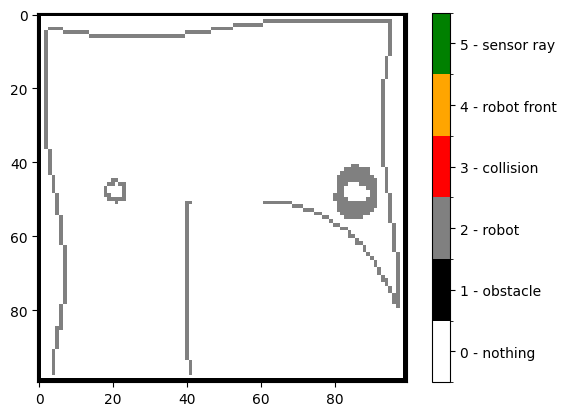

Grid occupancy per robot:
  Robot #1 captured 19 cells
  Robot #2 captured 48 cells
  Robot #3 captured 310 cells
  Robot #4 captured 112 cells
run no. 6 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 2.7638930113477365, 'rotations': 3.398112105001149, 'coverage': np.float64(0.0649), 'individual_coverages': array([0.0538, 0.0064, 0.0018, 0.0029])}


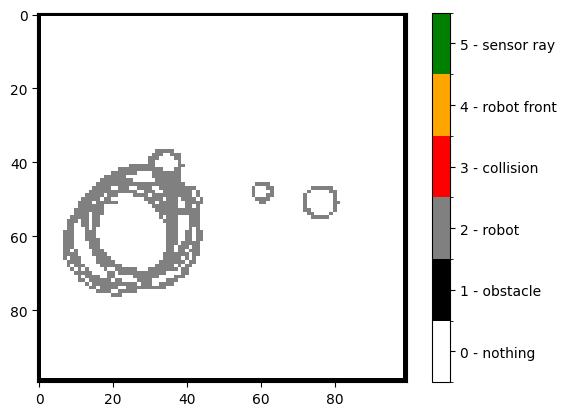

Grid occupancy per robot:
  Robot #1 captured 538 cells
  Robot #2 captured 64 cells
  Robot #3 captured 18 cells
  Robot #4 captured 29 cells
run no. 7 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 2.112220909207203, 'rotations': 3.768435339181005, 'coverage': np.float64(0.0094), 'individual_coverages': array([0.002 , 0.0034, 0.0004, 0.0036])}


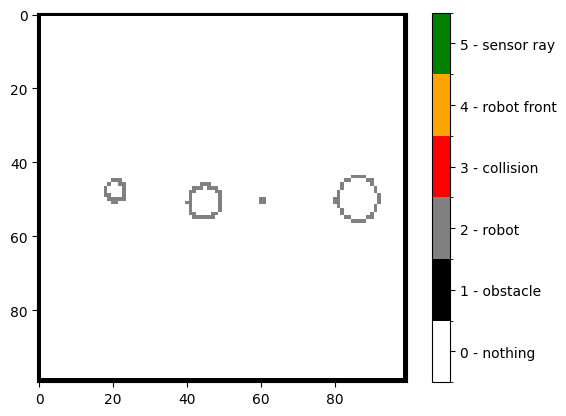

Grid occupancy per robot:
  Robot #1 captured 20 cells
  Robot #2 captured 34 cells
  Robot #3 captured 4 cells
  Robot #4 captured 36 cells
run no. 8 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 3.228561663154746, 'rotations': 2.7838398486107003, 'coverage': np.float64(0.0969), 'individual_coverages': array([0.0069, 0.0123, 0.0077, 0.07  ])}


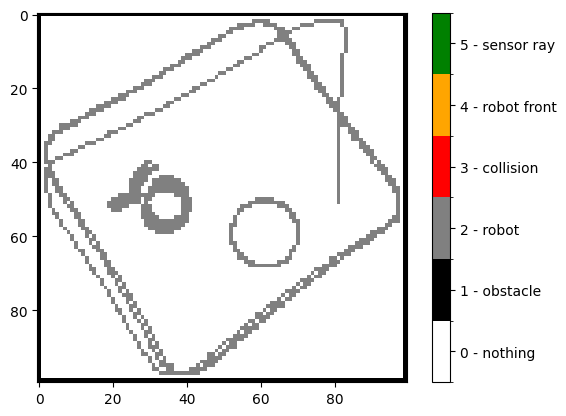

Grid occupancy per robot:
  Robot #1 captured 69 cells
  Robot #2 captured 123 cells
  Robot #3 captured 77 cells
  Robot #4 captured 700 cells
run no. 9 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 1.9181740760742956, 'rotations': 3.1236616844606235, 'coverage': np.float64(0.0728), 'individual_coverages': array([0.0011, 0.0037, 0.0669, 0.0011])}


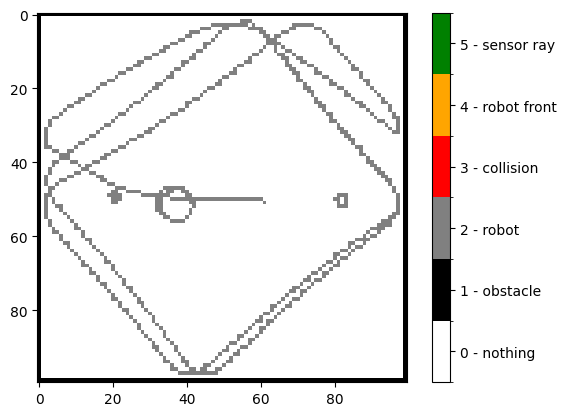

Grid occupancy per robot:
  Robot #1 captured 11 cells
  Robot #2 captured 37 cells
  Robot #3 captured 669 cells
  Robot #4 captured 11 cells
run no. 10 of 10
### iteration 0 / 1001 ###
### iteration 1000 / 1001 ###
{'translations': 0.7805355953749916, 'rotations': 0.8662621130894603, 'coverage': np.float64(0.0154), 'individual_coverages': array([0.0067, 0.002 , 0.0041, 0.0026])}


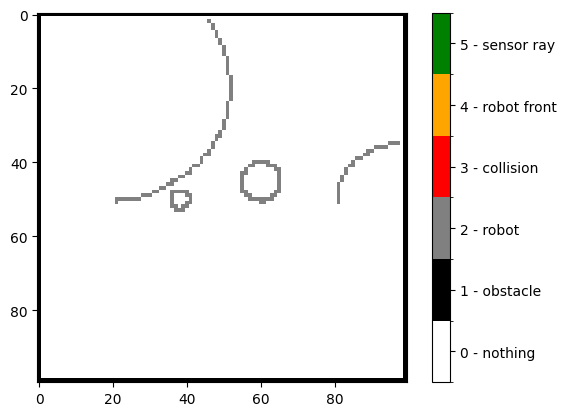

Grid occupancy per robot:
  Robot #1 captured 67 cells
  Robot #2 captured 20 cells
  Robot #3 captured 41 cells
  Robot #4 captured 26 cells


In [182]:
# policy function

class Robot_ANN(Robot):

  weights = []

  def __init__(self, x_0, y_0, theta_0, weights):
    self.weights = weights[:]
    super().__init__(x_0, y_0, theta_0)

  def step(self,sensors):
    translation = self.weights[0]*sensors[-2] + self.weights[1]*sensors[0] + self.weights[2]*sensors[2] + self.weights[3]*sensors[4] + self.weights[4]
    rotation = self.weights[5]*sensors[-2] + self.weights[6]*sensors[0] + self.weights[7]*sensors[2] + self.weights[8]*sensors[4] + self.weights[9]
    #print (sensors,translation,rotation,absolute_orientation)
    return translation,rotation

# Main

init()

print ("#\n# Multi-robots - random search on ANN controller\n#")

display_arena=False # diplay step-by-step if True.
verbose_minimal_progress = True # suggested: True -- useful. Tune gap_between_... to limit the nb of messages

#clear_arena()
create_arena_walls()

nb_robots = 4
robots = []

for i in range(nb_robots):
  robots.append( Robot_ANN( 20+i*20, arena_size//2, 90*i%360, np.random.uniform(-1.0, 1.0, size=10).tolist() ) )
  print ("Robot no.",robots[-1].id,"is alive")

nb_runs = 10
max_iterations = 1001 # 501 may be enough (if computer is slow)

for i in range(nb_runs):
  print ("run no.",(i+1),"of",nb_runs)
  weightss = np.random.uniform(-1.0, 1.0, size=10).tolist()
  for j in range(nb_robots):
    robots[j].reset() # reset position and orientation
    robots[j].weights = np.random.uniform(-1.0, 1.0, size=10).tolist()
  retValues = simulate(robots)
  #num_ones = np.count_nonzero(occupancy == 1)
  #print(num_ones)
  print (retValues)
  show_trace()
  # number of cells captured per robot (for each "cell", only the last visitor is registered)
  print("Grid occupancy per robot:")
  robot_ids, visited_cells = np.unique(occupancy, return_counts=True)
  for value, count in zip(robot_ids, visited_cells):
    if value != 0:
      print(f"  Robot #{value} captured {count} cells")


As was seen in previous TME, the RobotANN's MLP produces the same values for translations and rotations in the absence of stimuli, producing circular behavior. In other cases (near walls) it changes behavior usually being able to move away from them. The coverage varies in around 0.01-0.2.

---
---
---

#<font color="orange">Partie 2. Sujet</font>

Nous souhaitons optimiser le comportement de 4 robots pour une tâche de couverture de l'environnement. Du point de vue du groupe, il s'agit de couvrir le maximum de cases (ou cellule) de l'environnement, ce qui correspond ici aux pixels de l'arène. Du point de vue d'un robot seul, il s'agit de capturer le plus de cases possibles, sachant qu'une case "appartient" au dernier robot l'ayant visitée.

Nous allons comparer plusieurs dispositifs expérimentaux selon que l'on considère (1) un collectif homogène (ie. tous les robots utilisent les mêmes paramètres de contrôle pour leur réseaux de neurones) ou hétérogène (les paramètres sont propres à chacun), et (2) une assignation de la fitness au niveau du groupe ou de l'individu. Le sujet s'inspire des travaux de (Waibel et al. 2009) vus en cours.

Vous pouvez utiliser les concepts et les codes des deux précédents sujets, en particulier (1) les algorithmes (1+1)-ES 1/5e et CMAES, (2) le code pour tracer les courbes de résultats, (3) le code permettant de rejouer une simulation pas à pas (pas forcément utile).

Pour chaque question, vous tracerez sur un graphe l'évolution au cours du temps, en faisant figurer la performance du groupe, et les performances individuelles (ie. 5 courbes). L'axe X devra compter le nombre d'appels à la fonction *simulate* (qui est un meilleur indicateur du budget énergétique consommé). Vous sauvegarderez votre meilleur équipe pour eventuellement l'analyser ultérieurement.

*Un conseil avant de commencer: ce sujet vous demande d'utiliser ce que vous avez vu pendant les cours et TME précédents. Les questions sont de difficultés variables, n'hésitez pas à les faire dans le desordre. Voici une indication de l'ordre de difficulté: Q1,Q4 < Q2 < Q3 << Q5 <<<< Q6. Q6 est optionnelle.*

<font color="orange">Equipe homogène</font>

Dans l'approche homogène, ou "clonale", une équipe est constituée de plusieurs robots partageant les mêmes paramètres de contrôles (ici, les mêmes poids d'un réseau de neurones). Ces paramètres sont optimisés par un algorithme évolutionnaire. Du point de vue de l'algorithme, une solution candidate code donc l'ensemble de l'équipe. La performance est généralement évaluée pour l'ensemble de l'équipe. C'est à dire qu'une simulation donne une seule valeur de performance, ce qui correspond ici à la somme des cases capturées par l'équipe. Nous sommes ici donc un cas **coopératif**.

- **Q1**: Implémentez une approche clonale en utilisant l'algorithme (1+1)-ES et une fitness globale (ie. somme des scores de couverture de chaque robot). A vous de fixer les paramètres et le nombre d'itérations de l'algorithme. Analysez les comportements obtenus et commentez.

<font color="orange">Equipe hétérogène</font>

Dans l'approche hétérogène, l'équipe est composée de robots ayant chacun leurs propres paramètres de contrôle. Dans le dispositif le plus classique, l'évaluation se fait en une seule fois, avec tous les robots, et chaque robot se voit attribuée sa performance. Nous sommes ici dans un cas **compétitif**, même si en pratique la compétition n'est observée que s'il existe des conflits d'intérêt (ex.: compétition pour accéder à une ressource).

- **Q2**: Implémentez une approche hétérogène (ie. les paramètres de chaque robot sont optimisés par un algorithme dédié) en utilisant une fitness individuelle (ie. chaque robot optimise son score de couverture). Vous utiliserez un (1+1)-ES par robot. Tracez les résultats. Analysez les comportements obtenus et commentez.

- **Q3**: Implémentez une approche hétérogène en utilisant la fitness globale, c'est à dire que robot participe à l'optimisation du score de couverture de l'équipe. Tracez les résultats.

<font color="orange">Utilisation avec CMAES</font>

- **Q4**: Reprenez la question Q1 avec CMAES.

- **Q5**: (difficile) Reprenez la question Q2 avec CMAES. On aura donc une instance de CMAES par robot. Réflechissez bien à comment réaliser l'évaluation (si vous proposez un protocole d'évaluation différent, justifiez-le). Comparez et commentez les résultats.

<font color="orange">Question ouverte</font>

- **Q6** (difficile et très optionnelle): modifiez le simulateur pour ajouter un second type de senseurs capable de détecter si le senseur touche un mur ou un robot. Refaite la question Q2 avec (1+1)-ES. L'idée est qu'en permettant aux robots d'identifier leurs compétiteurs, on ouvre la voie à des interactions plus riches (suivi, obstruction, etc.).


In [183]:
def plot_data(
    data, title=None, x_label=None, y_label=None, interval=1, y_min=None, y_max=None, scale_x=1
):
    x_values = range(0, len(data), interval)
    y_values = data[::interval]
    x_ticks = range(len(data))[::interval]
    plt.figure(figsize=(5, 3))
    plt.plot(x_values, y_values, marker="o", linestyle="-", color="darkblue")
    if title is not None:
        plt.title(title)
    if x_label is not None:
        plt.xlabel(x_label)
    if y_label is not None:
        plt.ylabel(y_label)
    plt.grid(True)
    plt.xticks(x_ticks, labels= [str(tick*scale_x) for tick in x_ticks])
    plt.xticks(rotation=90)
    if y_min is not None and y_max is not None:
        plt.ylim(y_min, y_max)
    plt.show()


# Question 1

In [184]:
# (...à compléter...) - pour chaque question, créez une cellule texte avec comme titre de section "QUESTION XXX", suivi d'une cellule code.

In [185]:
def fitness_homogenous_team(weights):  # fitness function
    # global x_init, y_init, theta_init, weights
    
    for robot in robots:
        robot.reset() # reset position and orientation
        robot.weights = weights
    retValues = simulate(robots)

    fitness = retValues["coverage"] 

    if display_trace == True:  # noqa: E712
        show_trace()
    return fitness

In [186]:
def launch_oneplusone_withOneFifthRule(
    individual, sigma_init, nbeval, display, ma_func
):
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    sigma = sigma_init
    i = 0
    besteverFit = -float("inf")
    besteverIt = 0
    besteverSolution = individual
    data = []
    while i < nbeval:
        candidateSolution = np.random.randn(len(individual)) * sigma + besteverSolution
        fit = ma_func(candidateSolution)
        if fit >= besteverFit:
            besteverSolution = np.copy(candidateSolution)
            besteverFit = fit
            besteverIt = i
            sigma *= 2
        else:
            sigma *= 2 ** (-1 / 4)
        data.append(besteverFit)
        if display and i % (int(nbeval / 10)) == 0:
            print("it =", i, ", current_fit =", fit, ", best_fit =", besteverFit)
        i += 1
    print("Best fit", besteverFit, "found at iteration", besteverIt)
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    return besteverIt, besteverFit, besteverSolution, data

In [187]:
nb_runs = 3

Run 1 out of 3
Best fit 0.3148 found at iteration 43


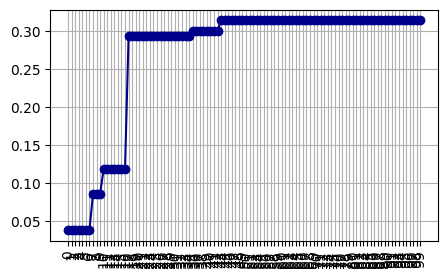

# Final state


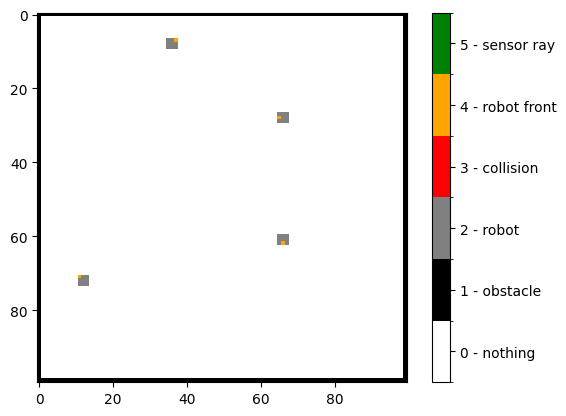

# Trajectory


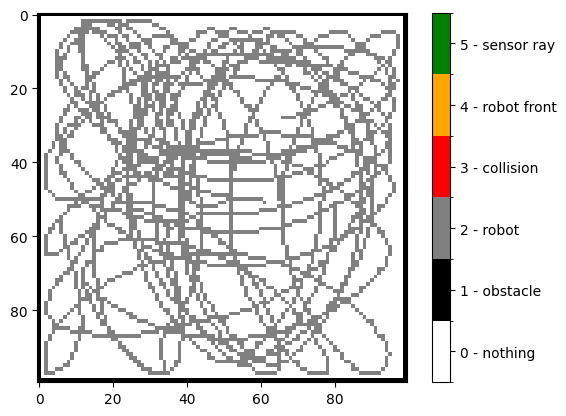

Run 2 out of 3
Best fit 0.3118 found at iteration 80


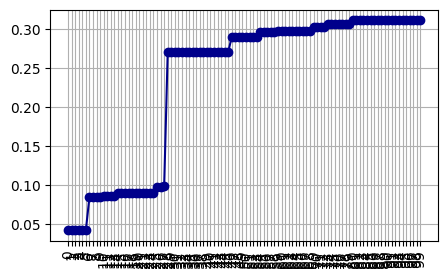

# Final state


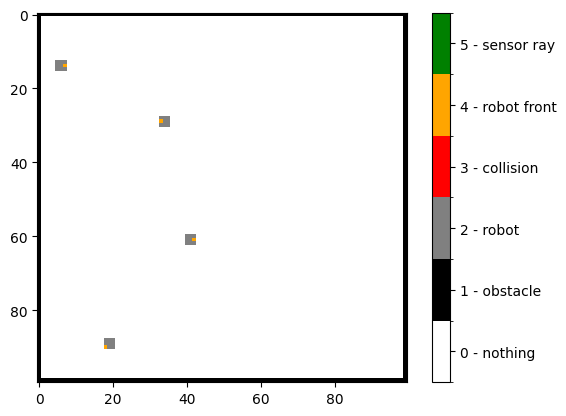

# Trajectory


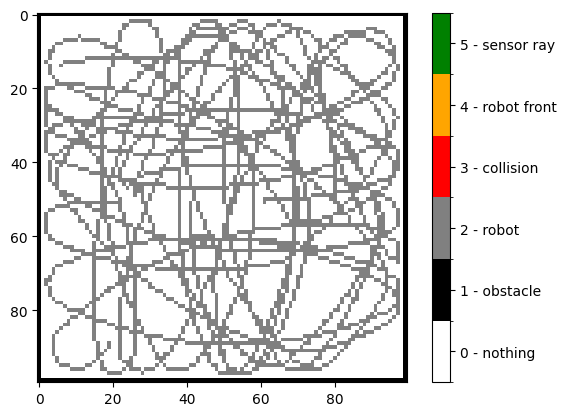

Run 3 out of 3
Best fit 0.0991 found at iteration 98


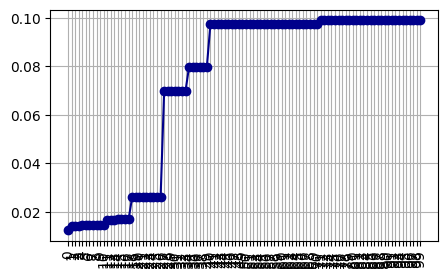

# Final state


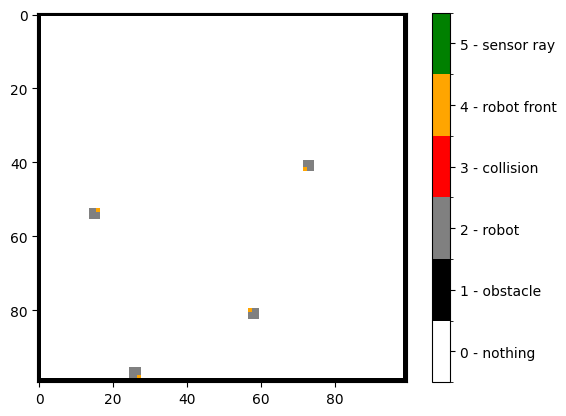

# Trajectory


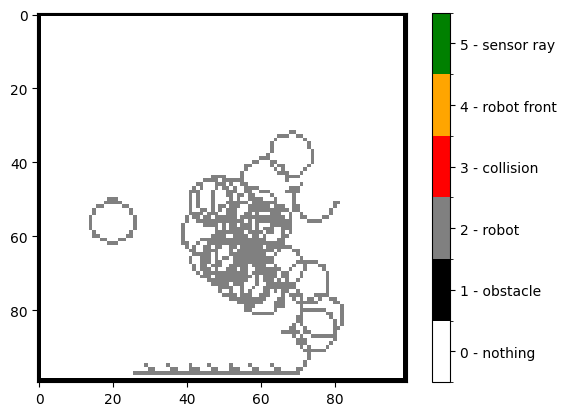

In [188]:
display_arena = False  # diplay step-by-step if True.
verbose_minimal_progress = (
    False  # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
)
display_trace = False

for run in range(nb_runs):
    print(f"Run {run+1} out of {nb_runs}")
    init_weights =  np.random.uniform(-1.0, 1.0, size=10).tolist()
    _,_,_, datas_individual = launch_oneplusone_withOneFifthRule(init_weights, 
                                    sigma_init=1,
                                    nbeval=100,
                                    display=False,
                                    ma_func=fitness_homogenous_team)
    plot_data(datas_individual)
    print ("# Final state")
    show_arena()
    print ("# Trajectory")
    show_trace()

We can see that this method, although increases final fitness (coverage), most of ES steps don't increase the score.

# Question 4

In [ ]:
def launch_cmaes(dim, display, ma_func, max_evaluations):
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !! !!!! !!!!!! !!!!!!
    
    popsize = 3 # NOTE: 10 =  4 + 3 * math.log(N) default for N=10
    es = cma.CMAEvolutionStrategy(
        x0=np.random.uniform(-1, 1, dim),
        sigma0=1,
        inopts={"maxfevals": max_evaluations, 
                "popsize": popsize 
                },
    )

    data = []
    while not es.stop():
        solutions = es.ask()
        es.tell(solutions, [-ma_func(s) for s in solutions])
        es.disp()
        print(data)
        data.append(-es.result.fbest)

    if display:
        plot_data(data, scale_x = popsize)
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    return es.result.fbest, es.result.xbest

Run 1 out of 3
(1,3mirr1)-aCMA-ES (mu_w=1.0,w_1=100%) in dimension 10 (seed=591474, Thu Mar 26 17:40:42 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      3 -1.254000000000000e-01 1.0e+00 9.72e-01  1e+00  1e+00 0:02.7
[]
    2      6 -1.790000000000000e-02 1.1e+00 9.89e-01  1e+00  1e+00 0:05.5
[0.1254]
    3      9 -1.420000000000000e-02 1.2e+00 9.76e-01  1e+00  1e+00 0:08.2
[0.1254, 0.1254]
    4     12 -6.360000000000000e-02 1.2e+00 9.02e-01  9e-01  1e+00 0:10.9
[0.1254, 0.1254, 0.1254]


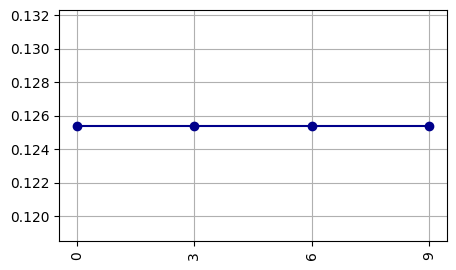

# Final state


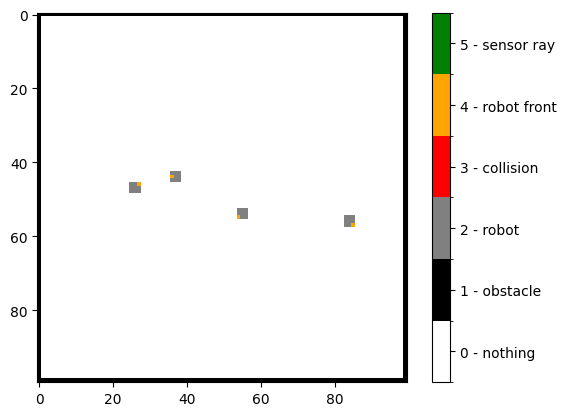

# Trajectory


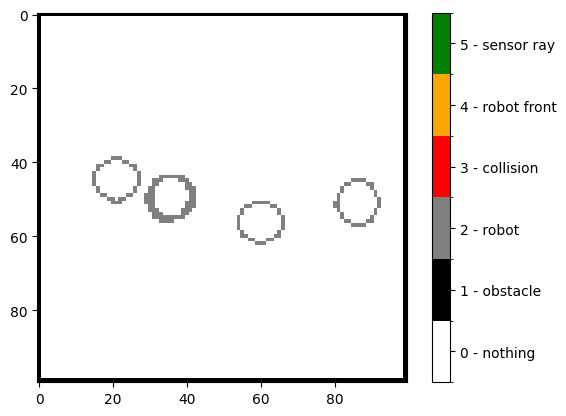

Run 2 out of 3
(1,3mirr1)-aCMA-ES (mu_w=1.0,w_1=100%) in dimension 10 (seed=607934, Thu Mar 26 17:40:53 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      3 -4.760000000000000e-02 1.0e+00 9.66e-01  9e-01  1e+00 0:02.7
[]
    2      6 -4.740000000000000e-02 1.1e+00 9.48e-01  9e-01  1e+00 0:05.5
[0.0476]
    3      9 -1.420000000000000e-02 1.1e+00 9.36e-01  9e-01  1e+00 0:08.3
[0.0476, 0.0476]
    4     12 -1.610000000000000e-02 1.1e+00 9.54e-01  9e-01  1e+00 0:11.0
[0.0476, 0.0476, 0.0476]


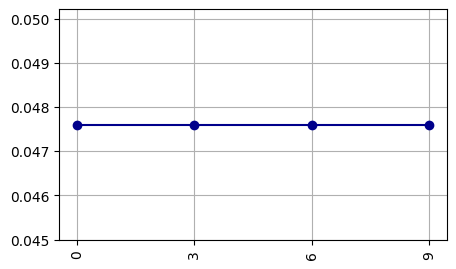

# Final state


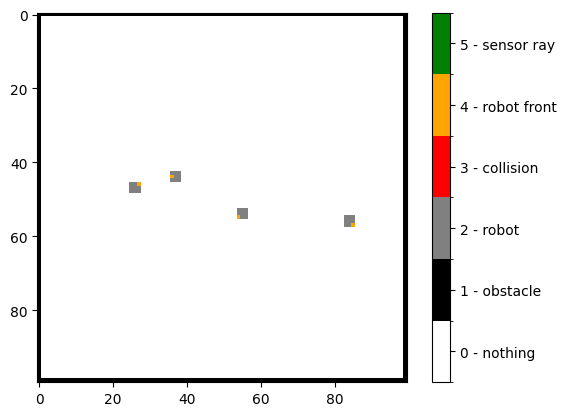

# Trajectory


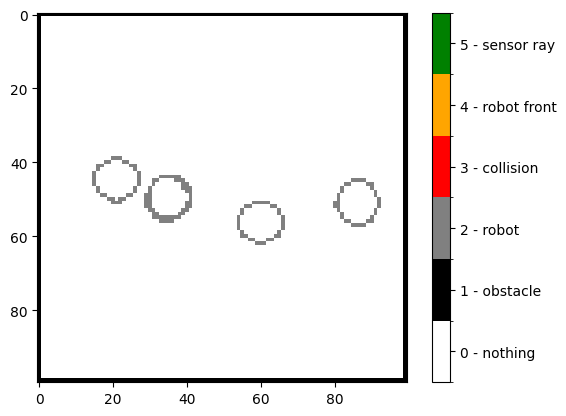

Run 3 out of 3
(1,3mirr1)-aCMA-ES (mu_w=1.0,w_1=100%) in dimension 10 (seed=638780, Thu Mar 26 17:41:04 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      3 -2.728000000000000e-01 1.0e+00 9.08e-01  9e-01  9e-01 0:02.9
[]
    2      6 -1.500000000000000e-02 1.0e+00 8.75e-01  9e-01  9e-01 0:05.7
[0.2728]
    3      9 -7.670000000000000e-02 1.1e+00 8.59e-01  8e-01  9e-01 0:08.4
[0.2728, 0.2728]
    4     12 -7.389999999999999e-02 1.1e+00 8.59e-01  8e-01  9e-01 0:11.2
[0.2728, 0.2728, 0.2728]


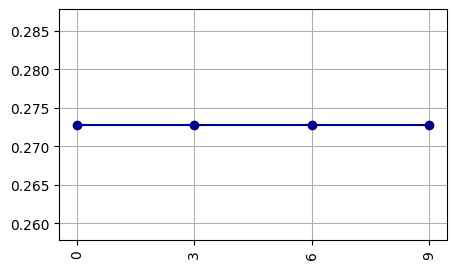

# Final state


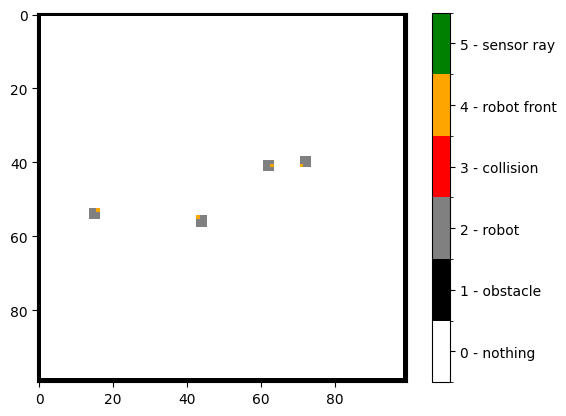

# Trajectory


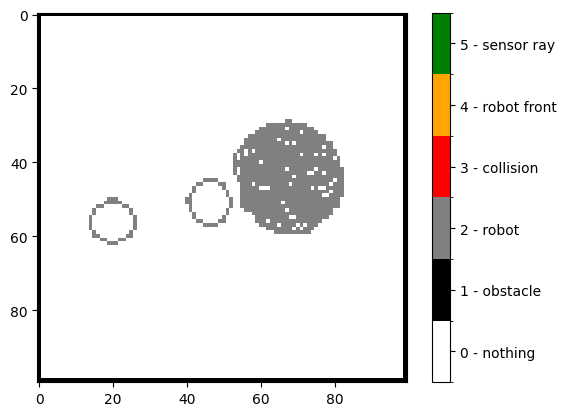

In [190]:
display_arena = False  # diplay step-by-step if True.
verbose_minimal_progress = (
    False  # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
)
display_trace = False

for run in range(nb_runs):
    print(f"Run {run+1} out of {nb_runs}")

    _, _ = launch_cmaes(len(weightss),
                        max_evaluations=10,
                        display=True,
                        ma_func=fitness_homogenous_team)
    print ("# Final state")
    show_arena()
    print ("# Trajectory")
    show_trace()

We can see that models converges faster and first iteration already is already good enough (coverage > 0.2).

CMA-ES sample `popsize` candidate solutions at each iteration step, each requiring a run of `simulate`. Thus the number of calls to `simulate` in CMA-ES optimization is `popsize * n_iters`.

In our case the convergence of CMAES is early due to the algorithm used in the `cma` library we are using. TODO: Why is this the case?

# Question 2

In [191]:
def fitnesses_individual(weightss):  # fitness function
    # global x_init, y_init, theta_init, weights
    
    for i, robot in enumerate(robots):
        robot.reset() # reset position and orientation
        robot.weights = weightss[i]

    retValues = simulate(robots)
    fitnesses = retValues["individual_coverages"] 
    fitness_global = retValues["coverage"]

    if display_trace == True:  # noqa: E712
        show_trace()
    return fitnesses, fitness_global

In [192]:
def launch_oneplusone_withOneFifthRuleIndividuals(
    weightss, sigmas_init, nb_evals, display, ma_func
):
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    sigmas = sigmas_init
    i = 0
    n = len(weightss) # number of robots
    best_fitnesses = np.array([-float("inf")] * n)
    best_is = np.zeros(n)
    best_solutions = weightss
    datas_individual = []
    data_global = []
    fitness_global = 0
    while i < nb_evals:
        candidate_solutions = np.random.randn(4, 10) * sigmas + best_solutions
        fitnesses, fitness_global = ma_func(candidate_solutions)
        for j in range(4):
            if fitnesses[j] >= best_fitnesses[j]:
                best_solutions[j] = np.copy(candidate_solutions[j])
                best_fitnesses[j] = fitnesses[j]
                best_is[j] = i
                sigmas[j] *= 2
            else:
                sigmas[j] *= 2 ** (-1 / 4)
        datas_individual.append(best_fitnesses.copy())
        data_global.append(ma_func(best_solutions)[1])
        if display and i % (int(nb_evals / 10)) == 0:
            print("iteration =", i, ", current_fitnesses =", fitnesses, ", best_fitnesses =", best_fitnesses)
        i += 1
    print("Best fit", best_fitnesses, "found at iteration", best_is)
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    print(f"Final Global Fitness: {fitness_global}")
    return best_is, best_fitnesses, best_solutions, np.array(datas_individual).T, data_global

Run 1 out of 3
Best fit [0.0914 0.0184 0.0505 0.0852] found at iteration [43. 13. 44. 68.]
Final Global Fitness: 0.1878


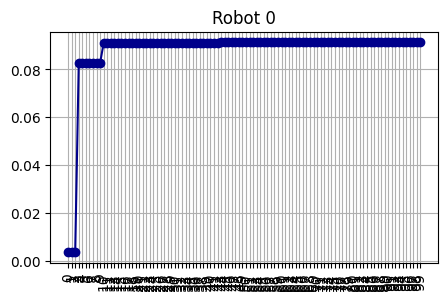

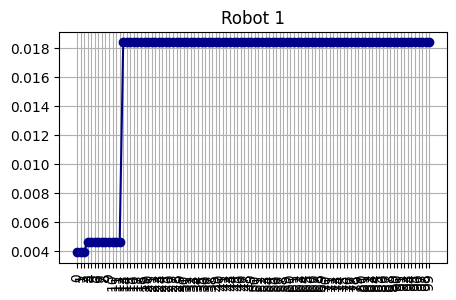

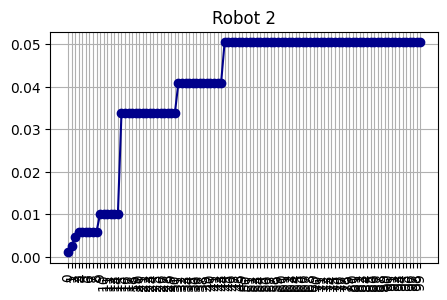

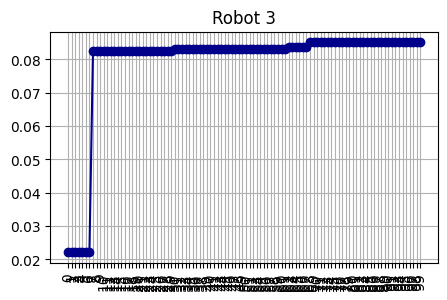

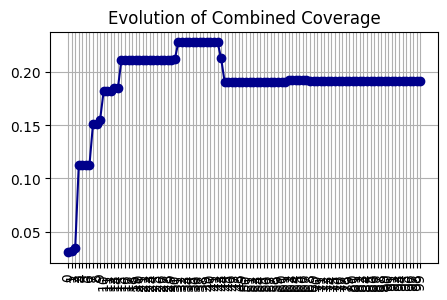

# Final state


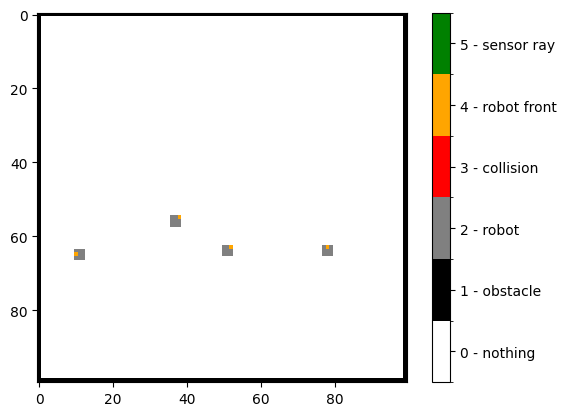

# Trajectory


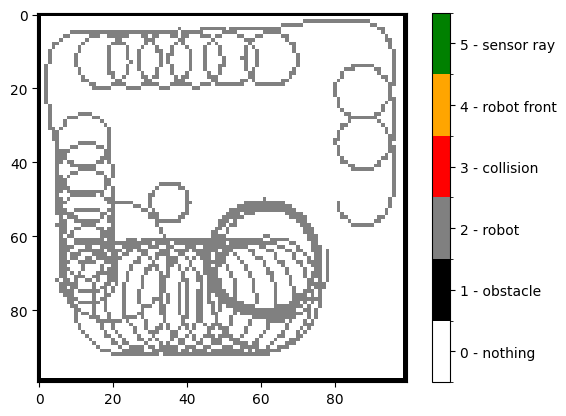

Run 2 out of 3
Best fit [0.0213 0.0888 0.078  0.088 ] found at iteration [20. 58. 90. 34.]
Final Global Fitness: 0.2469


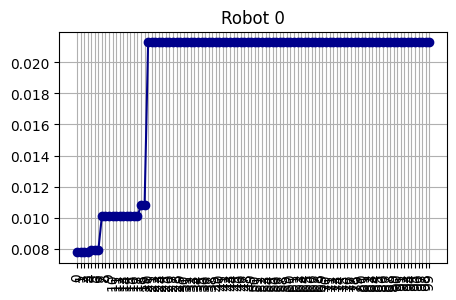

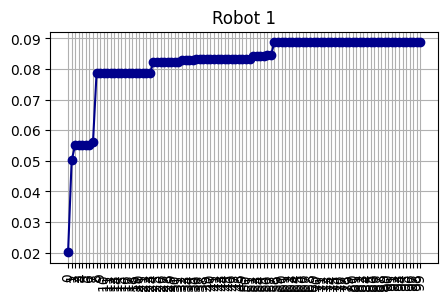

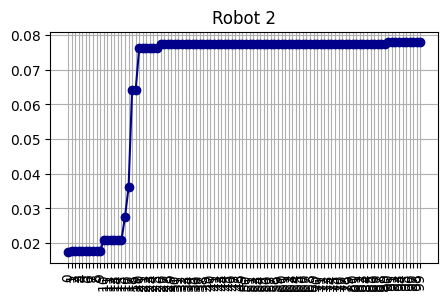

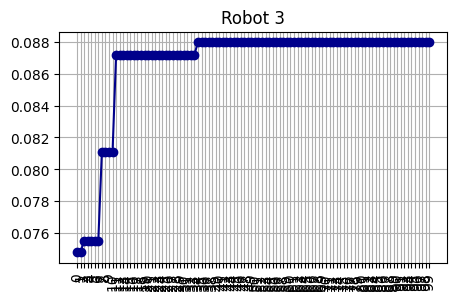

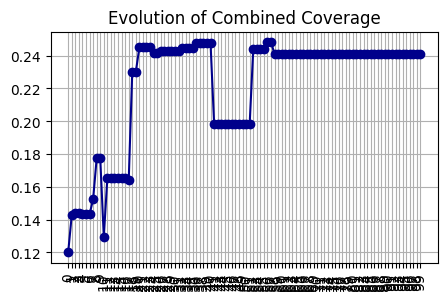

# Final state


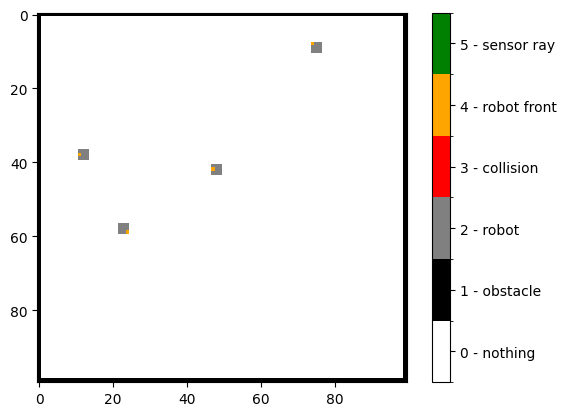

# Trajectory


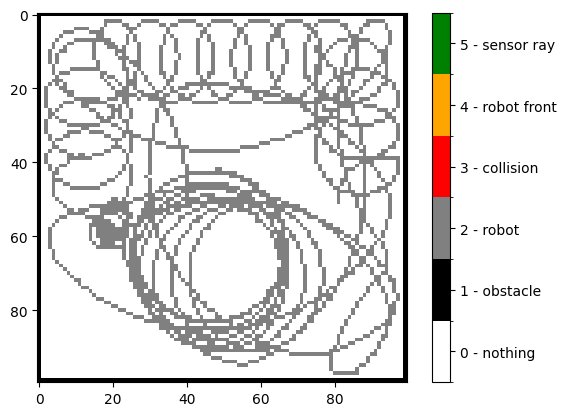

Run 3 out of 3
Best fit [0.0858 0.0801 0.0863 0.0226] found at iteration [24. 25. 34. 53.]
Final Global Fitness: 0.2289


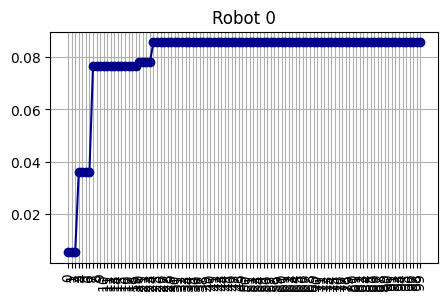

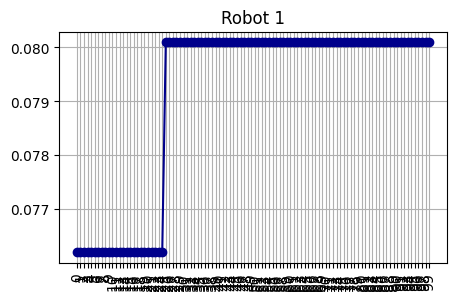

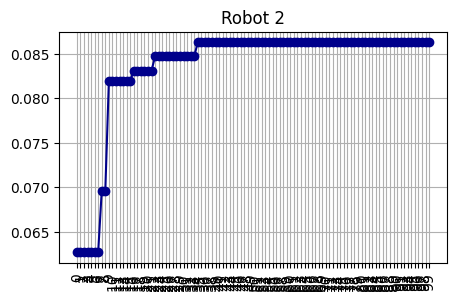

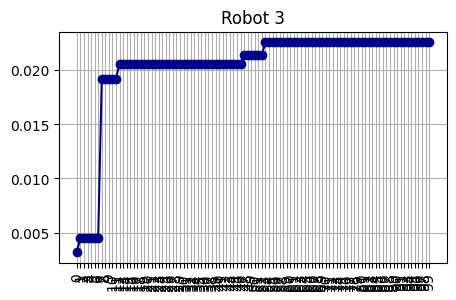

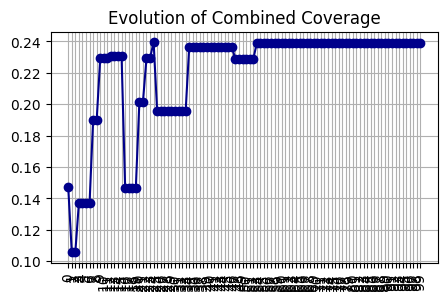

# Final state


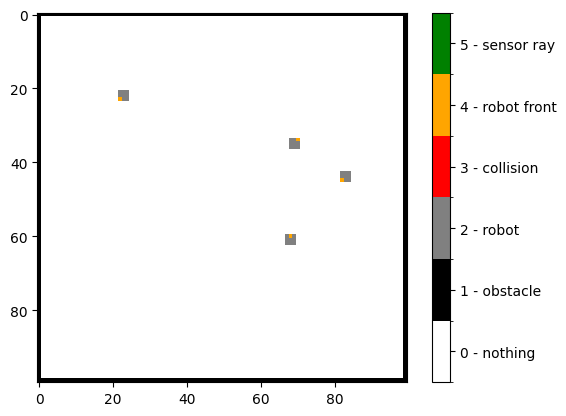

# Trajectory


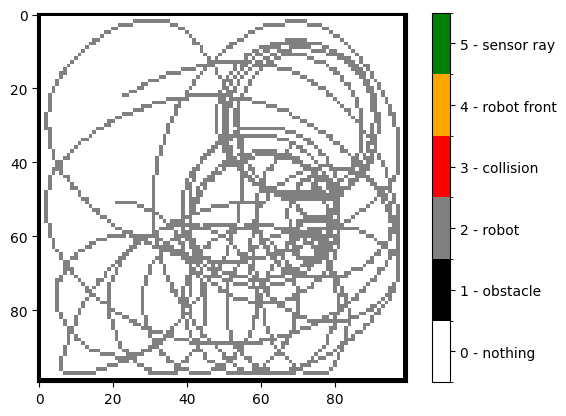

In [193]:
display_arena = False  # diplay step-by-step if True.
verbose_minimal_progress = (
    False  # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
)
display_trace = False

for run in range(nb_runs):
    print(f"Run {run+1} out of {nb_runs}")
    init_weightss =  np.random.uniform(-1.0, 1.0, size=(4, 10))
    _,_,best_soultuion, datas_individual, data_global = launch_oneplusone_withOneFifthRuleIndividuals(init_weightss, 
                                    sigmas_init=np.ones((4,1))*0.1,
                                    nb_evals=100,
                                    display=False,
                                    ma_func=fitnesses_individual)
    for i, data in enumerate(datas_individual):
        plot_data(data, title=f"Robot {i}")
    plot_data(data_global, title=f"Evolution of Combined Coverage")
    print ("# Final state")
    show_arena()
    print ("# Trajectory")
    show_trace()

So every robot improves individually and it results in the improvement of global fitness, sometimes it decreases due to lack of coordination between robots.

# Question 3

In [194]:
def launch_oneplusone_withOneFifthRuleIndividualsGlobal(
    weightss, sigma_init, nb_evals, display, ma_func
):
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    sigma = sigma_init
    i = 0
    n = len(weightss) # number of robots
    # best_fitnesses = np.array([-float("inf")] * n)
    best_fitness_global = -float("inf")
    # best_is = np.zeros(n)
    best_i = 0
    best_solutions = weightss
    # datas_individual = []
    data_global = []
    fitness_global = 0
    while i < nb_evals:
        candidate_solutions = np.random.randn(4, 10) * sigma + best_solutions
        fitnesses, fitness_global = ma_func(candidate_solutions)
        if fitness_global >= best_fitness_global:
                best_solutions = np.copy(candidate_solutions)
                best_fitness_global = fitness_global
                best_i = 0
                sigma *= 2
        else:
            sigma *= 2 ** (-1 / 4)
        # datas_individual.append(best_fitnesses.copy())
        data_global.append(best_fitness_global)
        if display and i % (int(nb_evals / 10)) == 0:
            print("iteration =", i, ", current_fitness =", fitness_global, ", best_fitness =", best_fitness_global)
        i += 1
    print("Best fit", best_fitness_global, "found at iteration", best_i)
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    print(f"Final Global Fitness: {fitness_global}")
    return best_i, best_fitness_global, best_solutions, None, data_global

Run 1 out of 3
Best fit 0.1293 found at iteration 0
Final Global Fitness: 0.126


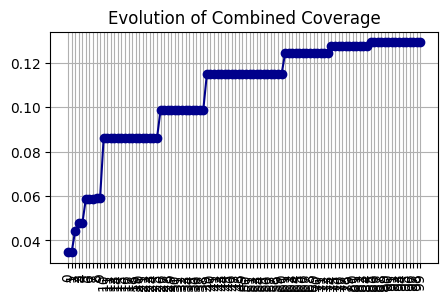

# Final state


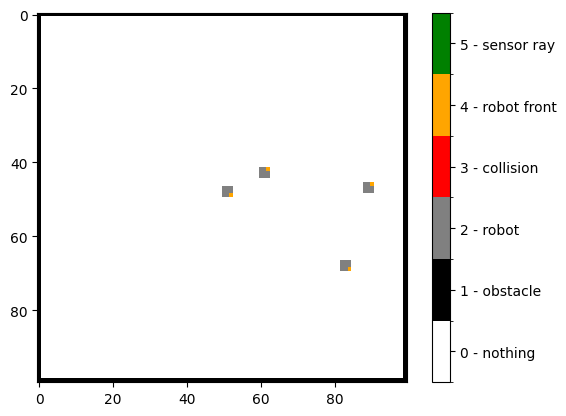

# Trajectory


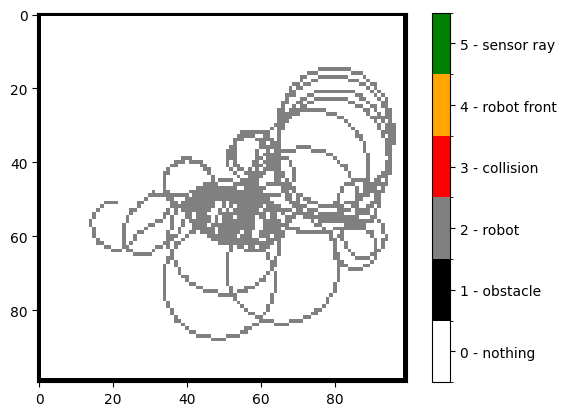

Run 2 out of 3
Best fit 0.16 found at iteration 0
Final Global Fitness: 0.1422


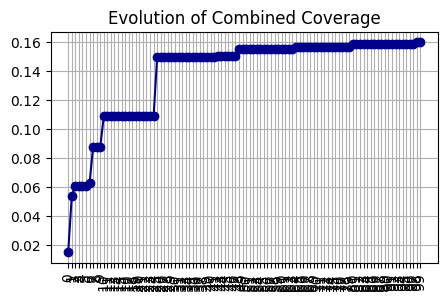

# Final state


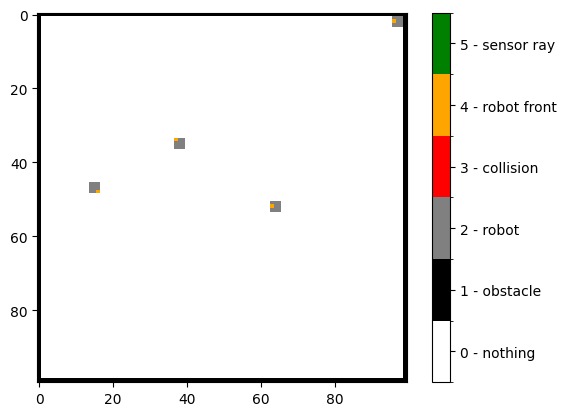

# Trajectory


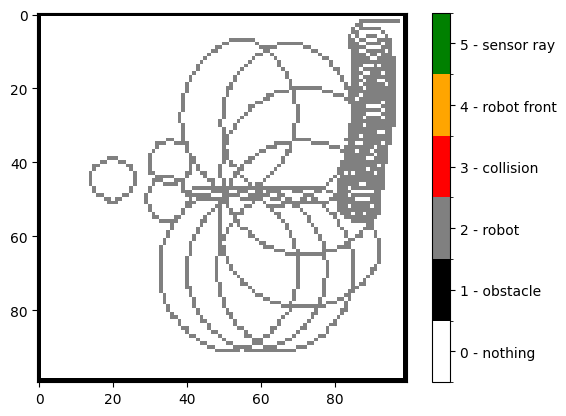

Run 3 out of 3
Best fit 0.1311 found at iteration 0
Final Global Fitness: 0.1241


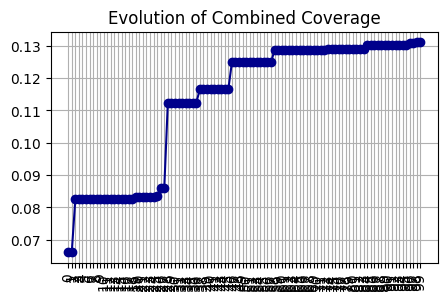

# Final state


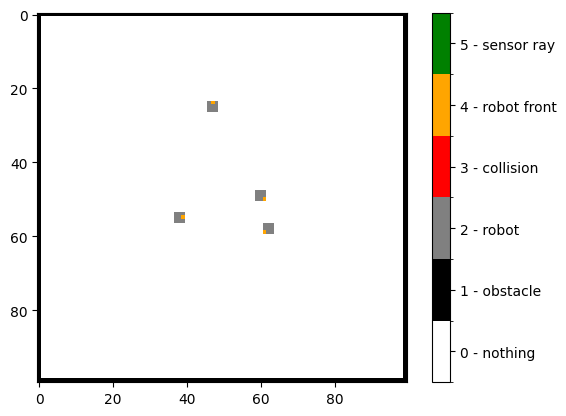

# Trajectory


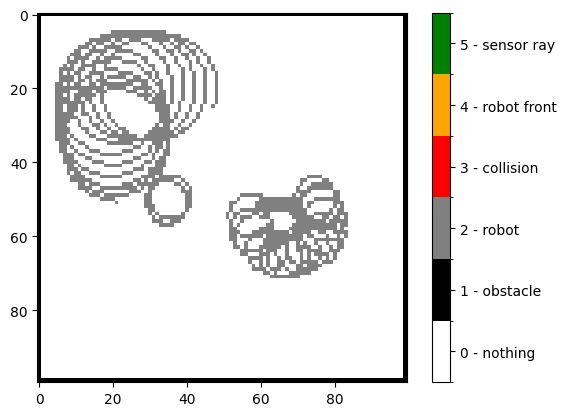

In [195]:
display_arena = False  # diplay step-by-step if True.
verbose_minimal_progress = (
    False  # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
)
display_trace = False

for run in range(nb_runs):
    print(f"Run {run+1} out of {nb_runs}")
    init_weightss =  np.random.uniform(-1.0, 1.0, size=(4, 10))
    _,_,best_solution, _, data_global = \
        launch_oneplusone_withOneFifthRuleIndividualsGlobal(init_weightss, 
                                    sigma_init=0.1,
                                    nb_evals=100,
                                    display=False,
                                    ma_func=fitnesses_individual)
    # for i, data in enumerate(datas_individual):
    #     plot_data(data, title=f"Robot {i}")
    plot_data(data_global, title=f"Evolution of Combined Coverage")
    print ("# Final state")
    show_arena()
    print ("# Trajectory")
    show_trace()

The model works to increase the "total/global" coverage value and somewhat succeeds. However this method is not as good as that of question 2 since one robot can slack off and will be compensated by the performance of the other robots.

# Question 5

In [196]:
def launch_cmaes_individual(dim, display, ma_func, max_evaluations):
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    
    popsize = 10 # NOTE: 10 =  4 + 3 * math.log(N) default for N=10
    eses = []
    
    for i in range(4):
        eses.append(
            cma.CMAEvolutionStrategy(
                x0 = np.random.uniform(-1, 1, 10)
            ),
            sigma0 = 1,
            inopts = {
                "maxfevals": max_evaluations,
                "popsize": popsize
            }
        )
    
    while not [es.stop() for es in eses]:
        for es in eses:
            solutions = es.ask()
            es.tell(solutions, -fitnesses_individual(s) for s in solutions)

    data = []
    while not es.stop():
        solutions = es.ask()
        es.tell(solutions, [-ma_funct(s) for s in solutions])
        es.disp()
        print(data)
        data.append(-es.result.fbest)

    if display:
        plot_data(data, scale_x = popsize)
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    return es.result.fbest, es.result.xbest

SyntaxError: Generator expression must be parenthesized (1153407058.py, line 22)

We did not manage to get CMA-ES to work with the problem from question 2. However in theory the performance of CMA-ES on this problem should theoretically not be good as CMA-ES assumes a static function but the simulate for each robot changes with the behavior of the other robots.

---
---
---

#<font color="orange">Fin du sujet.</font>

---
---
---
